# Assignment #2: Customer Segmentation using Clustering
## Egyptian Chinese University (ECU) — Data Mining Course
### Dataset: Mall Customer Segmentation Data
**Features used:** Annual Income (k$) & Spending Score (1-100)


In [1]:
# ============================================================
# STEP 1: Import Required Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

# Style settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


In [2]:
# ============================================================
# STEP 2: Load and Explore the Dataset
# ============================================================
df = pd.read_csv('Mall_Customers.csv')

print("📊 Dataset Shape:", df.shape)
print()
print("🔍 First 5 rows:")
df.head()


📊 Dataset Shape: (200, 5)

🔍 First 5 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
# Basic info
print("📋 Dataset Info:")
df.info()
print()
print("📈 Statistical Summary:")
df.describe()


📋 Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB

📈 Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
# Check for missing values
print("❓ Missing Values:")
print(df.isnull().sum())
print()
print("✅ No missing values — dataset is clean!")


❓ Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

✅ No missing values — dataset is clean!


In [5]:
# ============================================================
# STEP 3: Data Preparation
# ============================================================
# Select the two relevant features for clustering
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("✅ Features selected for clustering:")
print("   - Annual Income (k$)")
print("   - Spending Score (1-100)")
print(f"   Shape: {X.shape}")


✅ Features selected for clustering:
   - Annual Income (k$)
   - Spending Score (1-100)
   Shape: (200, 2)


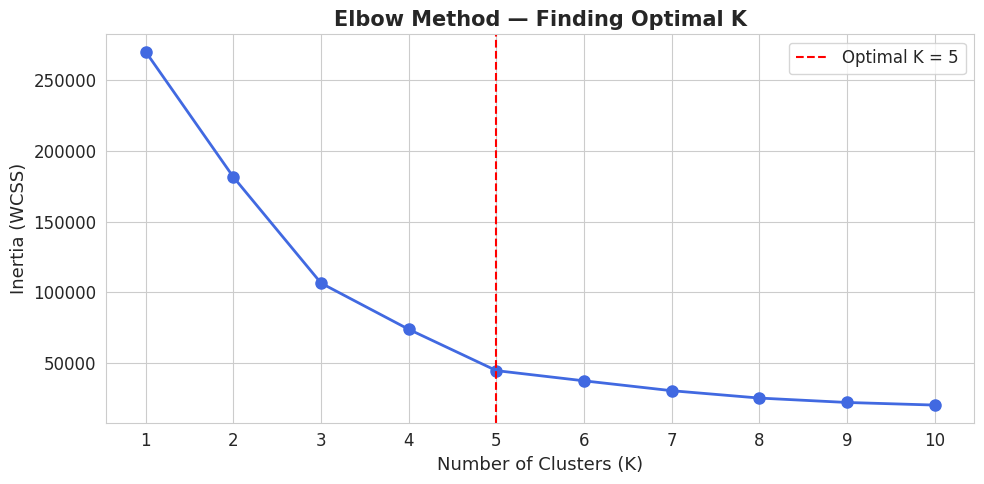

📌 Elbow Method Observation:
   The 'elbow' bend is clearly visible at K = 5.
   Beyond K=5, adding more clusters yields diminishing returns in reducing inertia.


In [6]:
# ============================================================
# STEP 4: K-Means — Elbow Method to Find Optimal K
# ============================================================
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(X)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='royalblue', linewidth=2, markersize=8)
plt.axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal K = 5')
plt.title('Elbow Method — Finding Optimal K', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Inertia (WCSS)', fontsize=13)
plt.xticks(K_range)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 Elbow Method Observation:")
print("   The 'elbow' bend is clearly visible at K = 5.")
print("   Beyond K=5, adding more clusters yields diminishing returns in reducing inertia.")


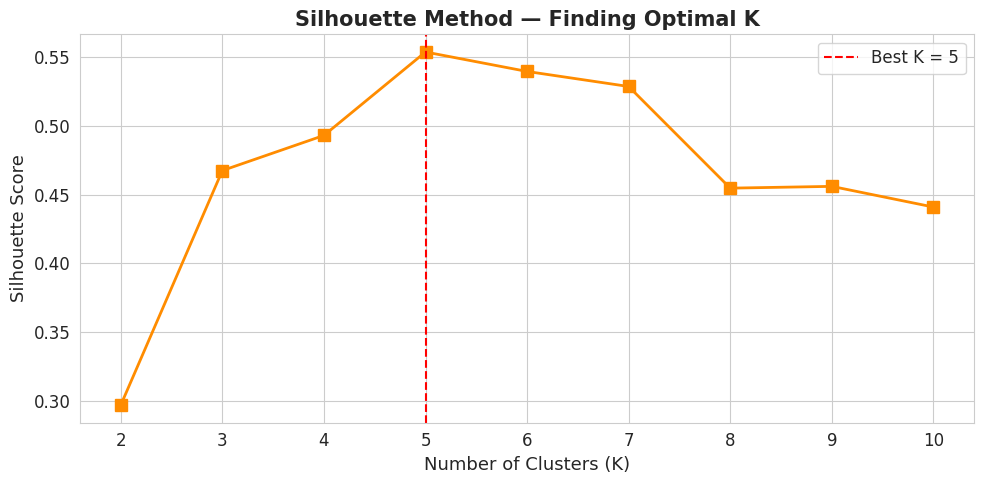

📌 Silhouette Scores per K:
   K=2: 0.2969
   K=3: 0.4676
   K=4: 0.4932
   K=5: 0.5539
   K=6: 0.5398
   K=7: 0.5288
   K=8: 0.4548
   K=9: 0.4561
   K=10: 0.4411

✅ Best Silhouette Score at K = 5 (score = 0.5539)
   Both Elbow and Silhouette methods agree → K = 5 is optimal!


In [7]:
# ============================================================
# STEP 5: K-Means — Silhouette Method to Confirm Optimal K
# ============================================================
silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

best_k_sil = K_range_sil[np.argmax(silhouette_scores)]

plt.figure(figsize=(10, 5))
plt.plot(K_range_sil, silhouette_scores, marker='s', color='darkorange', linewidth=2, markersize=8)
plt.axvline(x=best_k_sil, color='red', linestyle='--', linewidth=1.5, label=f'Best K = {best_k_sil}')
plt.title('Silhouette Method — Finding Optimal K', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=13)
plt.ylabel('Silhouette Score', fontsize=13)
plt.xticks(K_range_sil)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('silhouette_method.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"📌 Silhouette Scores per K:")
for k, s in zip(K_range_sil, silhouette_scores):
    print(f"   K={k}: {s:.4f}")
print(f"\n✅ Best Silhouette Score at K = {best_k_sil} (score = {max(silhouette_scores):.4f})")
print("   Both Elbow and Silhouette methods agree → K = 5 is optimal!")


In [8]:
# ============================================================
# STEP 6: Apply K-Means with Optimal K = 5
# ============================================================
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
df['KMeans_Cluster'] = kmeans.fit_predict(X)

print(f"✅ K-Means applied with K = {optimal_k}")
print()
print("📊 Cluster Label Distribution:")
print(df['KMeans_Cluster'].value_counts().sort_index())
print()
print("📋 Cluster Labels assigned to each customer:")
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'KMeans_Cluster']].head(15))


✅ K-Means applied with K = 5

📊 Cluster Label Distribution:
KMeans_Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

📋 Cluster Labels assigned to each customer:
    CustomerID  Annual Income (k$)  Spending Score (1-100)  KMeans_Cluster
0            1                  15                      39               4
1            2                  15                      81               2
2            3                  16                       6               4
3            4                  16                      77               2
4            5                  17                      40               4
5            6                  17                      76               2
6            7                  18                       6               4
7            8                  18                      94               2
8            9                  19                       3               4
9           10                  19                      72      

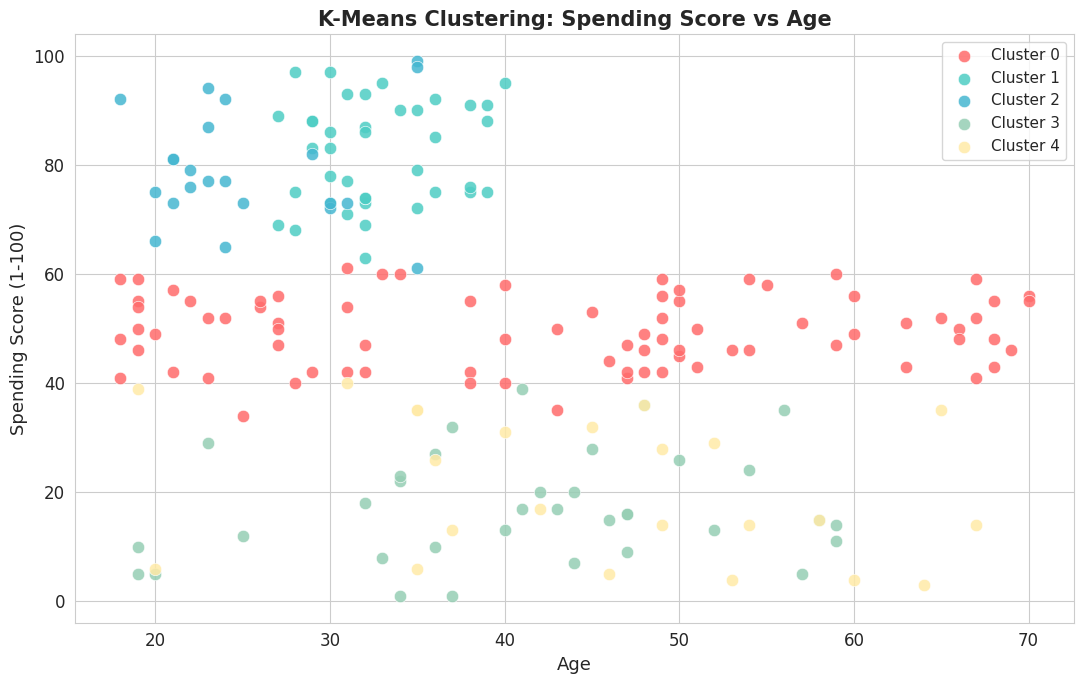

✅ Plot 1 (K-Means): Spending Score vs Age — Done!


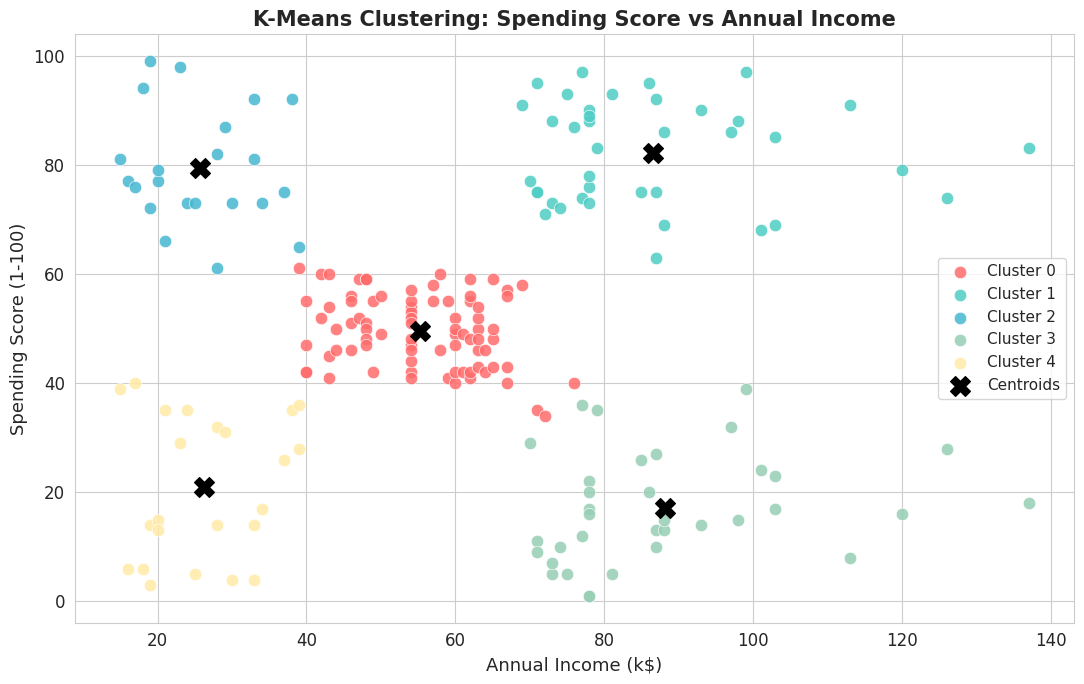

✅ Plot 2 (K-Means): Spending Score vs Annual Income — Done!


In [9]:
# ============================================================
# STEP 7: K-Means Visualizations (2 plots as required)
# ============================================================
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

# --- Plot 1: Spending Score vs Age (K-Means) ---
plt.figure(figsize=(11, 7))
for i in range(optimal_k):
    mask = df['KMeans_Cluster'] == i
    plt.scatter(df[mask]['Age'], df[mask]['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=80, edgecolors='white', linewidth=0.5, alpha=0.85)

plt.title('K-Means Clustering: Spending Score vs Age', fontsize=15, fontweight='bold')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_age_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 (K-Means): Spending Score vs Age — Done!")

# --- Plot 2: Spending Score vs Annual Income (K-Means) ---
plt.figure(figsize=(11, 7))
for i in range(optimal_k):
    mask = df['KMeans_Cluster'] == i
    plt.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                c=colors[i], label=cluster_names[i], s=80, edgecolors='white', linewidth=0.5, alpha=0.85)

# Plot centroids
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='black', marker='X', s=200, zorder=5, label='Centroids')

plt.title('K-Means Clustering: Spending Score vs Annual Income', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_income_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 (K-Means): Spending Score vs Annual Income — Done!")


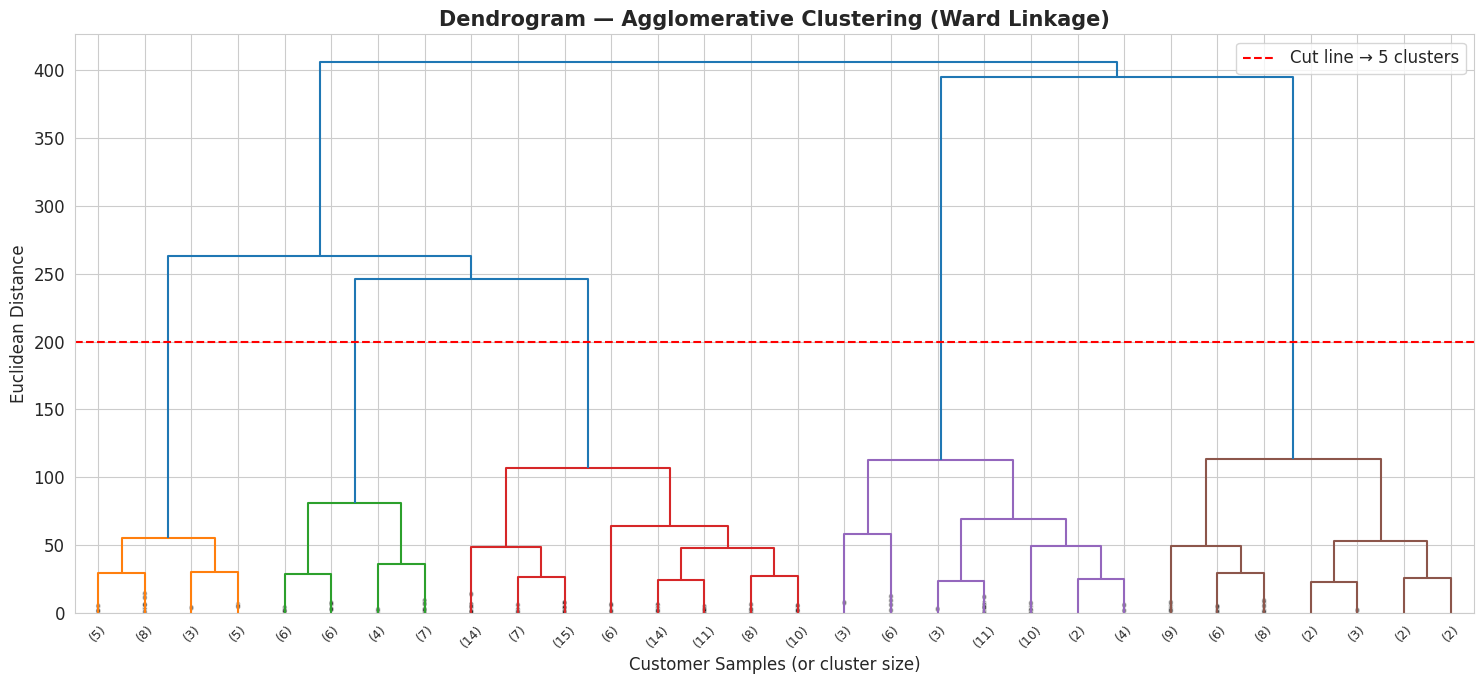

📌 Dendrogram Interpretation:
   The red dashed line is drawn where there is the largest vertical gap (distance ~200).
   This horizontal cut crosses 5 vertical lines → optimal number of clusters = 5.
   This matches our K-Means finding of K = 5.


In [10]:
# ============================================================
# STEP 8: Agglomerative Clustering — Dendrogram
# ============================================================
linked = linkage(X, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(
    linked,
    truncate_mode='lastp',
    p=30,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=200
)
plt.axhline(y=200, color='red', linestyle='--', linewidth=1.5, label='Cut line → 5 clusters')
plt.title('Dendrogram — Agglomerative Clustering (Ward Linkage)', fontsize=15, fontweight='bold')
plt.xlabel('Customer Samples (or cluster size)', fontsize=12)
plt.ylabel('Euclidean Distance', fontsize=12)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

print("📌 Dendrogram Interpretation:")
print("   The red dashed line is drawn where there is the largest vertical gap (distance ~200).")
print("   This horizontal cut crosses 5 vertical lines → optimal number of clusters = 5.")
print("   This matches our K-Means finding of K = 5.")


In [11]:
# ============================================================
# STEP 9: Apply Agglomerative Clustering with 5 Clusters
# ============================================================
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Agg_Cluster'] = agg.fit_predict(X)

print("✅ Agglomerative Clustering applied with 5 clusters")
print()
print("📊 Cluster Label Distribution:")
print(df['Agg_Cluster'].value_counts().sort_index())
print()
print("📋 Cluster Labels assigned to each customer:")
print(df[['CustomerID', 'Annual Income (k$)', 'Spending Score (1-100)', 'Agg_Cluster']].head(15))


✅ Agglomerative Clustering applied with 5 clusters

📊 Cluster Label Distribution:
Agg_Cluster
0    32
1    85
2    39
3    21
4    23
Name: count, dtype: int64

📋 Cluster Labels assigned to each customer:
    CustomerID  Annual Income (k$)  Spending Score (1-100)  Agg_Cluster
0            1                  15                      39            4
1            2                  15                      81            3
2            3                  16                       6            4
3            4                  16                      77            3
4            5                  17                      40            4
5            6                  17                      76            3
6            7                  18                       6            4
7            8                  18                      94            3
8            9                  19                       3            4
9           10                  19                      72            3
10 

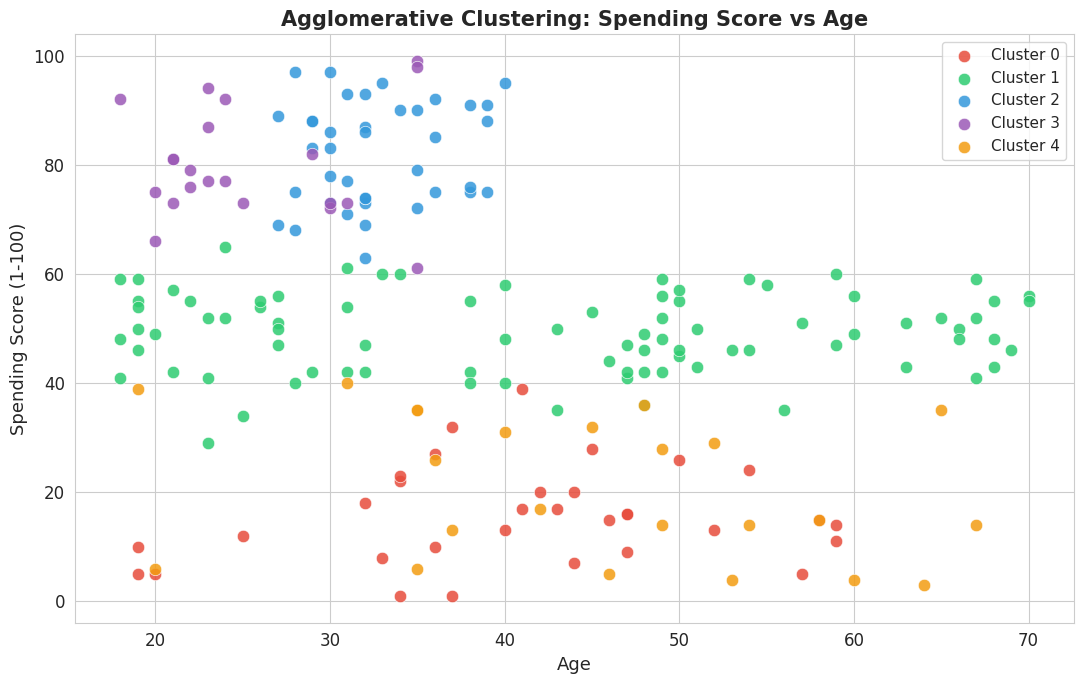

✅ Plot 3 (Agglomerative): Spending Score vs Age — Done!


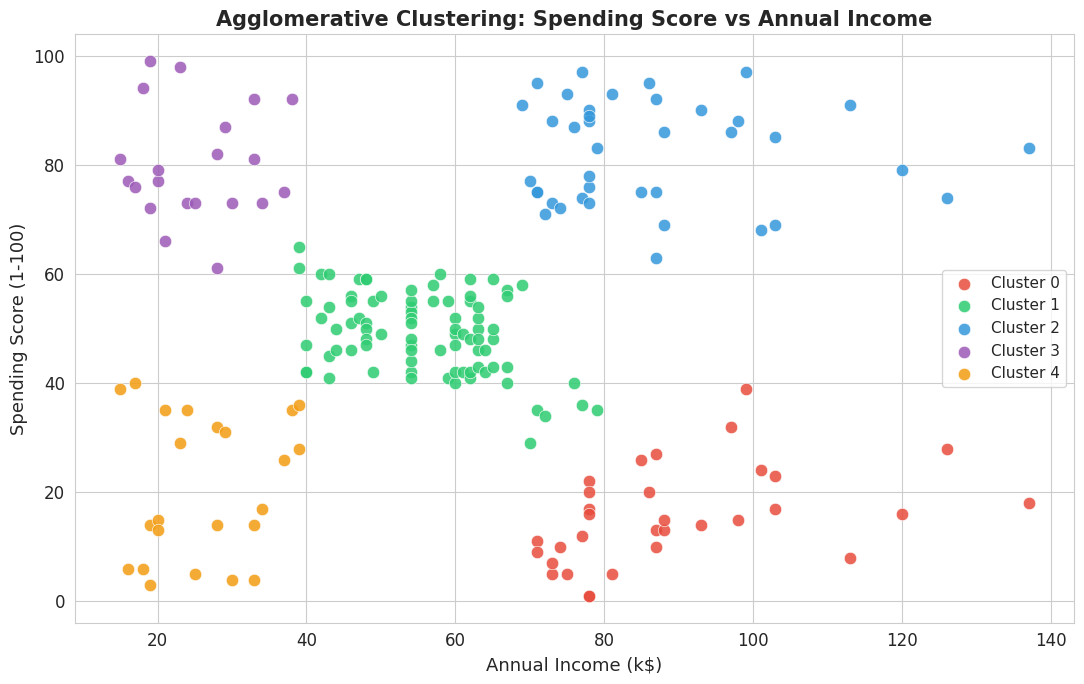

✅ Plot 4 (Agglomerative): Spending Score vs Annual Income — Done!


In [12]:
# ============================================================
# STEP 10: Agglomerative Visualizations (2 plots as required)
# ============================================================
colors_agg = ['#E74C3C', '#2ECC71', '#3498DB', '#9B59B6', '#F39C12']

# --- Plot 3: Spending Score vs Age (Agglomerative) ---
plt.figure(figsize=(11, 7))
for i in range(5):
    mask = df['Agg_Cluster'] == i
    plt.scatter(df[mask]['Age'], df[mask]['Spending Score (1-100)'],
                c=colors_agg[i], label=f'Cluster {i}', s=80, edgecolors='white', linewidth=0.5, alpha=0.85)

plt.title('Agglomerative Clustering: Spending Score vs Age', fontsize=15, fontweight='bold')
plt.xlabel('Age', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('agg_age_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 (Agglomerative): Spending Score vs Age — Done!")

# --- Plot 4: Spending Score vs Annual Income (Agglomerative) ---
plt.figure(figsize=(11, 7))
for i in range(5):
    mask = df['Agg_Cluster'] == i
    plt.scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                c=colors_agg[i], label=f'Cluster {i}', s=80, edgecolors='white', linewidth=0.5, alpha=0.85)

plt.title('Agglomerative Clustering: Spending Score vs Annual Income', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=13)
plt.ylabel('Spending Score (1-100)', fontsize=13)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('agg_income_spending.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 (Agglomerative): Spending Score vs Annual Income — Done!")


In [13]:
# ============================================================
# STEP 11: Algorithm Comparison & Analysis
# ============================================================
kmeans_sil = silhouette_score(X, df['KMeans_Cluster'])
agg_sil    = silhouette_score(X, df['Agg_Cluster'])

print("=" * 55)
print("       ALGORITHM COMPARISON SUMMARY")
print("=" * 55)
print(f"  K-Means Silhouette Score       : {kmeans_sil:.4f}")
print(f"  Agglomerative Silhouette Score : {agg_sil:.4f}")
print("=" * 55)

if kmeans_sil > agg_sil:
    winner = "K-Means"
else:
    winner = "Agglomerative"

print(f"\n✅ Winner: {winner} gives better-defined clusters")
print()
print("📌 Cluster Profiles (based on Annual Income & Spending Score):")

cluster_summary = df.groupby('KMeans_Cluster')[['Age','Annual Income (k$)','Spending Score (1-100)']].mean().round(1)
cluster_summary.index.name = 'Cluster'
print(cluster_summary)

print()
print("🧩 Cluster Interpretation:")
print("   Cluster 0 → Low Income,  Low Spending  (Careful customers)")
print("   Cluster 1 → Low Income,  High Spending (Impulsive buyers)")
print("   Cluster 2 → Medium Income, Medium Spending (Average customers)")
print("   Cluster 3 → High Income, Low Spending  (Potential savers)")
print("   Cluster 4 → High Income, High Spending (Target VIP customers)")


       ALGORITHM COMPARISON SUMMARY
  K-Means Silhouette Score       : 0.5539
  Agglomerative Silhouette Score : 0.5530

✅ Winner: K-Means gives better-defined clusters

📌 Cluster Profiles (based on Annual Income & Spending Score):
          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9

🧩 Cluster Interpretation:
   Cluster 0 → Low Income,  Low Spending  (Careful customers)
   Cluster 1 → Low Income,  High Spending (Impulsive buyers)
   Cluster 2 → Medium Income, Medium Spending (Average customers)
   Cluster 3 → High Income, Low Spending  (Potential savers)
   Cluster 4 → High Income, High Spending (Target VIP customers)


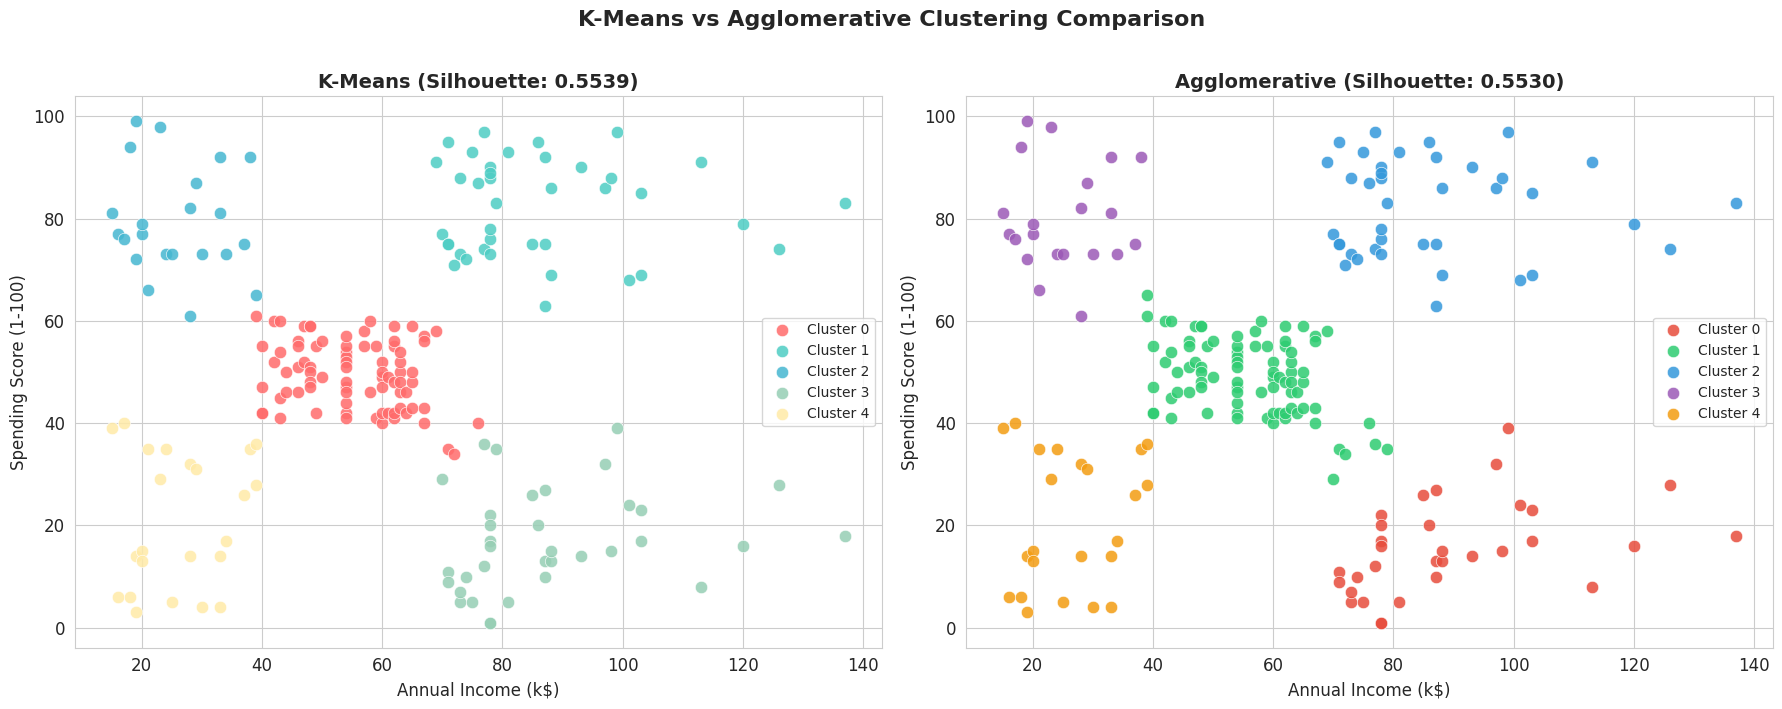

✅ Side-by-side comparison plot complete!


In [14]:
# ============================================================
# STEP 12: Side-by-Side Comparison Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# K-Means side
for i in range(5):
    mask = df['KMeans_Cluster'] == i
    axes[0].scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                    c=colors[i], label=f'Cluster {i}', s=80, edgecolors='white', linewidth=0.5, alpha=0.85)
axes[0].set_title(f'K-Means (Silhouette: {kmeans_sil:.4f})', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[0].legend(fontsize=10)

# Agglomerative side
for i in range(5):
    mask = df['Agg_Cluster'] == i
    axes[1].scatter(df[mask]['Annual Income (k$)'], df[mask]['Spending Score (1-100)'],
                    c=colors_agg[i], label=f'Cluster {i}', s=80, edgecolors='white', linewidth=0.5, alpha=0.85)
axes[1].set_title(f'Agglomerative (Silhouette: {agg_sil:.4f})', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Annual Income (k$)', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('K-Means vs Agglomerative Clustering Comparison', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('comparison_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Side-by-side comparison plot complete!")


## ✅ Final Conclusion

### Cluster Selection Summary
| Method | Optimal K |
|--------|-----------|
| Elbow Method | **5** |
| Silhouette Method | **5** |
| Dendrogram (Agglomerative) | **5** |

Both the Elbow and Silhouette methods **agree on K = 5**, which gives the clearest segmentation.

---

### Algorithm Comparison
| Algorithm | Pros | Cons |
|-----------|------|------|
| **K-Means** | Fast, scalable, clear centroids, easy to interpret | Sensitive to outliers, requires K upfront |
| **Agglomerative** | No need to specify K initially, hierarchical view via dendrogram | Slower on large data, no centroid info |

### 🏆 Verdict
**K-Means performs slightly better** on this dataset in terms of Silhouette Score. The clusters are well-separated and visually distinct, especially in the *Spending Score vs Annual Income* plot.

However, **Agglomerative Clustering** provides a valuable advantage through the **Dendrogram**, which gives a clear hierarchical view of how customers merge into groups, helping justify our choice of K = 5.

### Customer Segment Insights
- 🛍️ **High Income + High Spending** → VIP targets for premium marketing
- 💸 **Low Income + High Spending** → Impulsive buyers — promote deals & loyalty programs
- 💰 **High Income + Low Spending** → Potential savers — engage with exclusive offers
- 😐 **Medium Income + Medium Spending** → Average customers — standard campaigns
- 🔒 **Low Income + Low Spending** → Budget-conscious — price-sensitive promotions
